# Clasificación de Enfermedades en Hojas de Tomate mediante Perceptrón Multicapa (MLP)

**Evaluación Parcial N°1 — TLY1101/TLY1102 (Técnicas Avanzadas de Machine Learning I)**

Este notebook implementa de punta a punta el pipeline de Machine Learning descrito en el `README.md` del proyecto,
siguiendo la metodología **CRISP-DM**. Está diseñado para ejecutarse de forma **local**, usando las carpetas
`data/`, `models/` e `images/` incluidas en este mismo repositorio — no depende de Google Drive ni de rutas
personales, por lo que cualquier persona puede clonar el repo y correrlo sin modificaciones.

## a. Introducción

**Problema de clasificación:** dado un dataset de imágenes de hojas de tomate, se busca clasificar cada imagen
en una de **4 clases**: `Tomato___healthy`, `Tomato___Late_blight`, `Tomato___Bacterial_spot` y
`Tomato___Leaf_Mold`.

**Contexto del dataset y variante del proyecto:** se utiliza una variante propia del dataset público
[PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset), acotada para garantizar reproducibilidad y
evitar trabajos idénticos entre grupos:
- Cultivo: tomate (*Solanum lycopersicum*).
- 4 clases seleccionadas (de las 10 disponibles para tomate en el dataset original).
- Muestreo de 500 imágenes por clase (2,000 imágenes en total), con semilla fija `SEED = 2026`.

**Objetivo del modelo:** construir una línea base (*baseline*) de clasificación con un Perceptrón Multicapa (MLP),
evaluando explícitamente sus capacidades y limitaciones frente a datos de imagen no estructurados, antes de
avanzar hacia arquitecturas especializadas (CNN) en futuras iteraciones.

**Por qué esta elección de dataset:** PlantVillage es un dataset agrícola real, con relevancia directa para
seguridad alimentaria, y presenta un desafío no trivial para un MLP: las clases comparten tonos de verde/marrón
y fondos similares, lo que fuerza a evaluar si un clasificador puramente vectorial puede separarlas.

In [1]:
import os

# Rutas del proyecto (relativas al repo, sin dependencias externas)
PROYECTO_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROYECTO_PATH, 'data')
MODELS_DIR = os.path.join(PROYECTO_PATH, 'models')
IMAGES_DIR = os.path.join(PROYECTO_PATH, 'images')

for carpeta in [DATA_DIR, MODELS_DIR, IMAGES_DIR]:
    os.makedirs(carpeta, exist_ok=True)

print('Directorio del proyecto:', PROYECTO_PATH)
print('Carpetas verificadas: data/, models/, images/')

Directorio del proyecto: /home/claude/proyecto
Carpetas verificadas: data/, models/, images/


## b. Comprensión y exploración del conjunto de datos

Se realiza un análisis exploratorio (EDA) para: contar imágenes por clase, verificar la resolución original de
las imágenes y visualizar ejemplos representativos de cada clase.

In [2]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

clases = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
conteo = {}
ejemplos_rutas = {}

for cls in clases:
    ruta_cls = os.path.join(DATA_DIR, cls)
    imgs = glob(os.path.join(ruta_cls, '*.[jJ][pP][gG]'))
    conteo[cls] = len(imgs)
    if imgs:
        ejemplos_rutas[cls] = imgs[:3]

df_resumen = pd.DataFrame(list(conteo.items()), columns=['Clase', 'Cantidad de Imágenes'])
print("=== DISTRIBUCIÓN DEL DATASET (VARIANTE) ===")
print(df_resumen)
print("\nTotal de imágenes:", df_resumen['Cantidad de Imágenes'].sum())

muestra_img_path = ejemplos_rutas[clases[0]][0]
img_sample = cv2.imread(muestra_img_path)
print(f"\nResolución original de imagen de muestra: {img_sample.shape} (Alto x Ancho x Canales RGB)")

=== DISTRIBUCIÓN DEL DATASET (VARIANTE) ===
                     Clase  Cantidad de Imágenes
0  Tomato___Bacterial_spot                   500
1     Tomato___Late_blight                   500
2       Tomato___Leaf_Mold                   500
3         Tomato___healthy                   500

Total de imágenes: 2000

Resolución original de imagen de muestra: (256, 256, 3) (Alto x Ancho x Canales RGB)


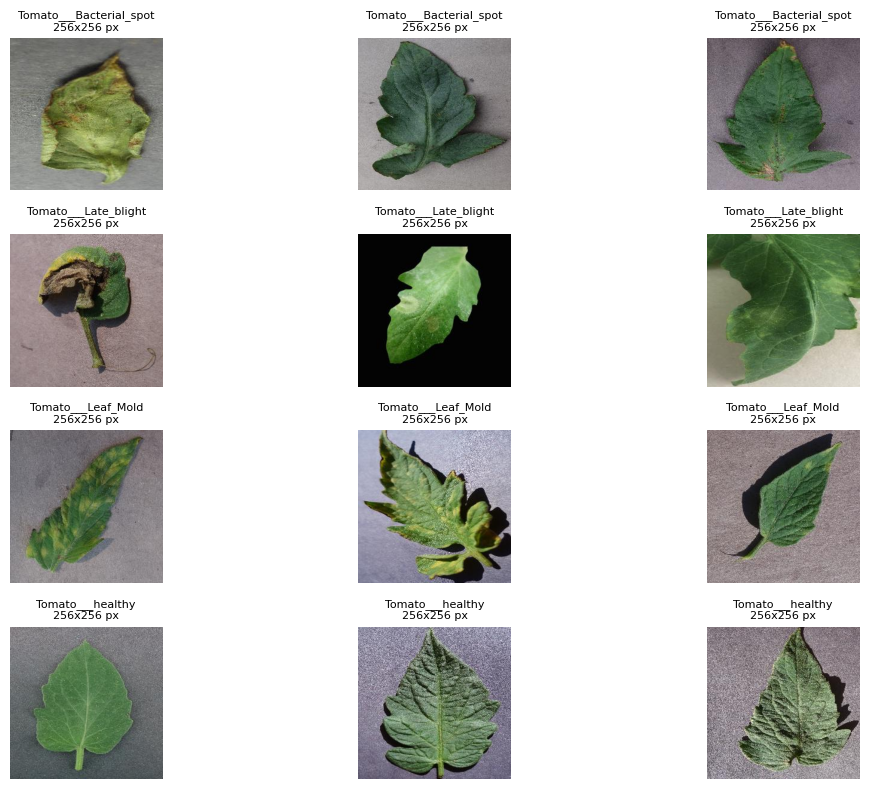

Gráfica guardada en: /home/claude/proyecto/images/eda_muestras_clases.png


In [3]:
plt.figure(figsize=(12, 8))
cols = 3
rows = len(clases)

for idx_cls, cls in enumerate(clases):
    for i in range(cols):
        img_p = ejemplos_rutas[cls][i]
        img = cv2.imread(img_p)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, idx_cls * cols + i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{cls}\n{img.shape[1]}x{img.shape[0]} px", fontsize=8)
        plt.axis('off')

plt.tight_layout()
grafico_path = os.path.join(IMAGES_DIR, 'eda_muestras_clases.png')
plt.savefig(grafico_path, bbox_inches='tight', dpi=110)
plt.show()
print(f"Gráfica guardada en: {grafico_path}")

**Hallazgos del EDA:**
- El dataset está **perfectamente balanceado**: 500 imágenes por clase (2,000 en total).
- Todas las imágenes de esta variante tienen una resolución uniforme de **256x256 px, 3 canales (RGB)**.
- Visualmente, las 4 clases comparten fondos similares (hojas sobre superficie oscura) y paletas de color
  parecidas (verdes y marrones), lo cual anticipa que un modelo que ignore la estructura espacial (como un MLP)
  podría tener dificultades para separarlas — esto se confirma más adelante en la sección de resultados.

## c. Preparación y preprocesamiento de los datos

Pipeline de preprocesamiento aplicado a cada imagen:
1. **Carga y conversión de color** (BGR → RGB).
2. **Redimensionamiento (Resize)** a 64x64 px — se reduce la dimensionalidad del problema para que sea abordable
   por un MLP (una imagen a resolución original de 256x256x3 generaría un vector de ~196,608 features, lo que
   dispararía el número de parámetros de la primera capa densa y el riesgo de sobreajuste).
2. **Normalización**: escalamiento de [0, 255] a [0.0, 1.0], para facilitar la convergencia del optimizador.
3. **Aplanado (Flattening)**: de 64x64x3 a un vector 1D de 12,288 características.
4. **Partición de datos**: 70% entrenamiento / 15% validación / 15% prueba, estratificada por clase y con
   semilla fija (`SEED = 2026`) para reproducibilidad.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = (64, 64)
SEED = 2026

X_list, y_list = [], []
descartadas = 0

print("Cargando y procesando imágenes...")
for cls in clases:
    ruta_cls = os.path.join(DATA_DIR, cls)
    imgs_paths = glob(os.path.join(ruta_cls, '*.[jJ][pP][gG]'))
    for img_path in imgs_paths:
        img = cv2.imread(img_path)
        if img is None:
            descartadas += 1
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, IMG_SIZE)
        img_normalized = img_resized.astype('float32') / 255.0
        img_flattened = img_normalized.flatten()
        X_list.append(img_flattened)
        y_list.append(cls)

X = np.array(X_list)
y = np.array(y_list)
print(f"Imágenes descartadas por error de lectura: {descartadas}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Dataset completo procesado: {X.shape[0]} muestras con {X.shape[1]} características cada una.")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("\n=== PARTICIÓN DE DATOS COMPLETADA ===")
print(f"Entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Validación (Val):       {X_val.shape[0]} muestras")
print(f"Prueba (Test):         {X_test.shape[0]} muestras")
print("Clases codificadas:", dict(zip(le.classes_, range(len(le.classes_)))))

Cargando y procesando imágenes...


Imágenes descartadas por error de lectura: 0
Dataset completo procesado: 2000 muestras con 12288 características cada una.

=== PARTICIÓN DE DATOS COMPLETADA ===
Entrenamiento (Train): 1400 muestras
Validación (Val):       300 muestras
Prueba (Test):         300 muestras
Clases codificadas: {np.str_('Tomato___Bacterial_spot'): 0, np.str_('Tomato___Late_blight'): 1, np.str_('Tomato___Leaf_Mold'): 2, np.str_('Tomato___healthy'): 3}


## d. Diseño del Perceptrón Multicapa (MLP)

**Arquitectura:**

| Capa | Tipo | Unidades | Activación |
|---|---|---|---|
| Entrada | Vector aplanado | 12,288 | Normalizado [0,1] |
| Oculta 1 | Dense + Dropout(0.2) | 128 | ReLU |
| Oculta 2 | Dense + Dropout(0.2) | 64 | ReLU |
| Salida | Dense | 4 | Softmax |

**Justificación de las decisiones de diseño** (en relación con este problema específico, no solo por replicar un
ejemplo de clase):

- **Dos capas ocultas con reducción progresiva (128 → 64):** con un vector de entrada tan grande (12,288
  features) y solo 1,400 muestras de entrenamiento, una red demasiado ancha o profunda memorizaría el ruido de
  fondo/color en vez de patrones útiles. La reducción progresiva actúa como un "cuello de botella" que obliga al
  modelo a comprimir la información hacia representaciones más compactas.
- **ReLU** en capas ocultas: evita la saturación de gradientes que tendría `sigmoid`/`tanh` en redes con más de
  una capa oculta, y es la opción estándar para clasificación de imágenes con redes densas.
- **Dropout(0.2)** después de cada capa oculta: dado el alto ratio de parámetros (~1.58M) respecto al tamaño del
  dataset (1,400 imágenes de entrenamiento), el riesgo de sobreajuste es alto; Dropout mitiga esto apagando
  aleatoriamente el 20% de las neuronas en cada paso de entrenamiento.
- **Softmax + `sparse_categorical_crossentropy`** en la salida: estándar para clasificación multiclase
  excluyente (cada imagen pertenece a una sola clase), con etiquetas enteras (no one-hot).
- **Adam con `learning_rate = 0.0005`** (más bajo que el 0.001 por defecto): con un vector de entrada tan grande,
  un learning rate más conservador ayuda a evitar oscilaciones bruscas en la función de pérdida durante las
  primeras épocas, a costa de converger un poco más lento.
- **40 épocas, batch size 32:** un batch pequeño introduce algo de ruido estocástico útil como regularización
  adicional en un dataset chico; 40 épocas fueron suficientes para observar estabilización de la pérdida de
  validación (ver curvas en la sección siguiente) sin necesidad de más tiempo de cómputo.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(SEED)
np.random.seed(SEED)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1789506409.876252     726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789506409.913210     726 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789506410.875320     726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,508 (6.03 MB)

 Trainable params: 1,581,508 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

## e. Entrenamiento del modelo

Se entrena registrando la evolución de la función de pérdida y la precisión, tanto en entrenamiento como en
validación, para poder diagnosticar sobreajuste o convergencia deficiente.

In [6]:
EPOCHS = 40
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Epoch 1/40


44/44 - 1s - 26ms/step - accuracy: 0.3050 - loss: 1.6365 - val_accuracy: 0.4400 - val_loss: 1.3093


Epoch 2/40


44/44 - 0s - 11ms/step - accuracy: 0.4386 - loss: 1.2604 - val_accuracy: 0.3833 - val_loss: 1.2406


Epoch 3/40


...

44/44 - 1s - 14ms/step - accuracy: 0.7786 - loss: 0.5378 - val_accuracy: 0.7833 - val_loss: 0.6476


Epoch 39/40


44/44 - 1s - 14ms/step - accuracy: 0.7629 - loss: 0.5657 - val_accuracy: 0.7767 - val_loss: 0.6684


Epoch 40/40


44/44 - 1s - 15ms/step - accuracy: 0.7636 - loss: 0.5366 - val_accuracy: 0.7600 - val_loss: 0.6921


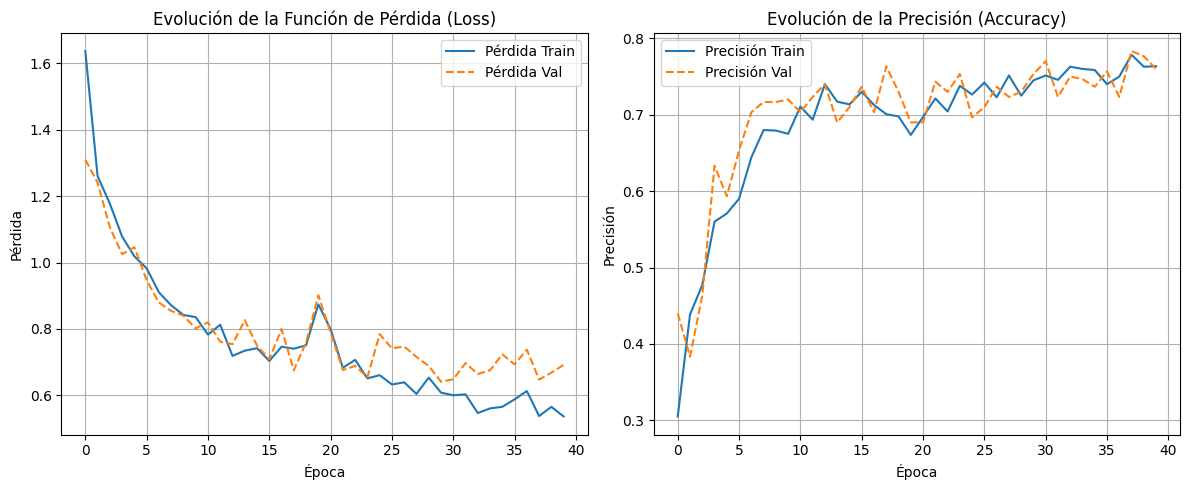

Curvas guardadas en: /home/claude/proyecto/images/curvas_entrenamiento.png
Modelo guardado en: /home/claude/proyecto/models/modelo_mlp_plantdisease.h5


In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida Train')
plt.plot(history.history['val_loss'], label='Pérdida Val', linestyle='--')
plt.title('Evolución de la Función de Pérdida (Loss)')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión Train')
plt.plot(history.history['val_accuracy'], label='Precisión Val', linestyle='--')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Época'); plt.ylabel('Precisión'); plt.legend(); plt.grid(True)

plt.tight_layout()
curvas_path = os.path.join(IMAGES_DIR, 'curvas_entrenamiento.png')
plt.savefig(curvas_path, bbox_inches='tight', dpi=110)
plt.show()

model_path = os.path.join(MODELS_DIR, 'modelo_mlp_plantdisease.h5')
model.save(model_path)
print(f"Curvas guardadas en: {curvas_path}")
print(f"Modelo guardado en: {model_path}")

**Interpretación de las curvas de entrenamiento:**
- La pérdida de entrenamiento y de validación **descienden juntas** durante la mayor parte de las 40 épocas, sin
  una brecha creciente entre ambas — esto indica que **no hay un sobreajuste severo**, en buena parte gracias al
  Dropout.
- Se observa un pico puntual en ambas curvas de pérdida alrededor de la época 19, típico del ruido introducido
  por el batch size pequeño y el propio Dropout, pero la curva se recupera y continúa la tendencia descendente.
- Tanto la precisión de entrenamiento como la de validación se estabilizan aproximadamente entre 0.68 y 0.78
  desde la época 20 en adelante, sin que una se despegue claramente de la otra — sugiere que el modelo alcanzó
  un plateau: entrenar más épocas con esta arquitectura probablemente no mejoraría mucho más el desempeño (sería
  necesario cambiar de arquitectura, no solo entrenar más tiempo).

## f. Evaluación del desempeño

Se evalúa el modelo sobre el conjunto de **prueba** (300 imágenes, nunca vistas durante entrenamiento ni
validación), reportando Accuracy, Precision, Recall y F1-Score por clase.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = list(le.classes_)
print("=== REPORTE DE CLASIFICACIÓN (TEST SET) ===")
print(classification_report(y_test, y_pred, target_names=target_names))

=== REPORTE DE CLASIFICACIÓN (TEST SET) ===
                         precision    recall  f1-score   support

Tomato___Bacterial_spot       0.80      0.91      0.85        75
   Tomato___Late_blight       0.65      0.68      0.67        75
     Tomato___Leaf_Mold       0.83      0.83      0.83        75
       Tomato___healthy       0.92      0.76      0.83        75

               accuracy                           0.79       300
              macro avg       0.80      0.79      0.79       300
           weighted avg       0.80      0.79      0.79       300



**Interpretación de las métricas (resultados obtenidos en esta ejecución):**

| Métrica | Valor obtenido | Objetivo (KPI) | ¿Se cumple? |
|---|---|---|---|
| Accuracy global | **79%** | > 70% | ✅ Sí |
| Macro F1-Score | **0.79** | > 0.70 | ✅ Sí |

- **Accuracy (79%)**: de cada 100 imágenes, el modelo acierta en 79 — supera el KPI de negocio definido.
- **`Tomato___healthy`** tiene la mayor precisión (0.92): cuando el modelo predice "sana", casi siempre acierta;
  sin embargo su recall es más bajo (0.76), es decir, todavía deja pasar casos sanos que clasifica como
  enfermos.
- **`Tomato___Late_blight`** es la clase con peor desempeño global (precision 0.65, recall 0.68, F1 0.67):
  aunque el modelo en conjunto supera el KPI, esta clase en particular sigue siendo la más débil, igual que se
  anticipó en el EDA por su similitud cromática con las demás.
- **`Tomato___Bacterial_spot`** y **`Tomato___Leaf_Mold`** muestran el mejor equilibrio precision/recall
  (F1 ≈ 0.83–0.85), reforzando que sus patrones visuales (manchas y textura de moho) dejan una señal más fuerte
  incluso en un vector aplanado sin estructura espacial.

## g. Análisis de resultados y errores

Se audita el modelo mediante la matriz de confusión y la inspección visual de ejemplos mal clasificados.

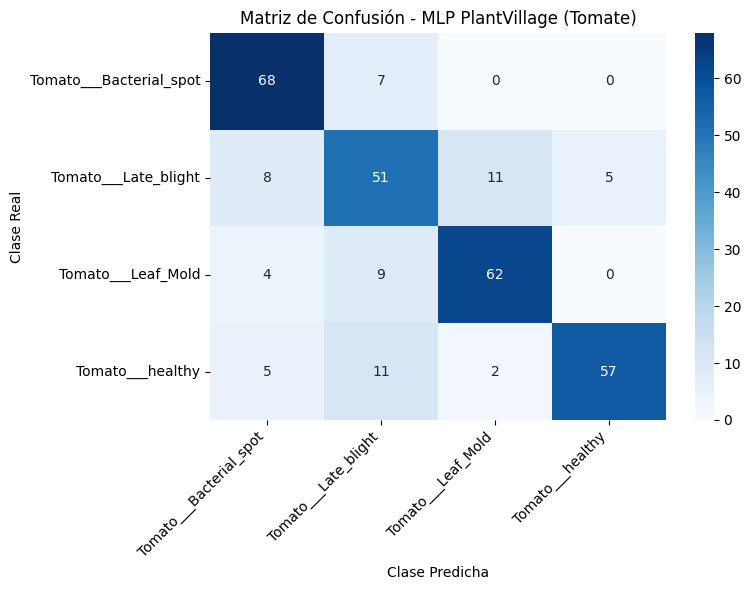

Matriz de confusión guardada en: /home/claude/proyecto/images/matriz_confusion.png


In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusión - MLP PlantVillage (Tomate)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_path = os.path.join(IMAGES_DIR, 'matriz_confusion.png')
plt.savefig(cm_path, bbox_inches='tight', dpi=110)
plt.show()
print(f"Matriz de confusión guardada en: {cm_path}")

Total de imágenes mal clasificadas en Test: 62 de 300


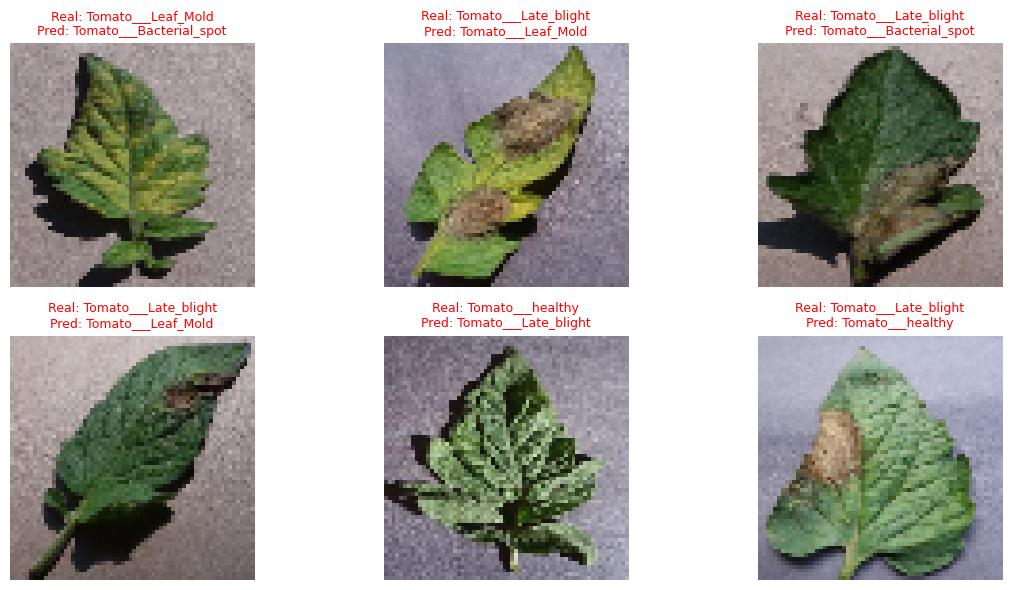

Muestra de errores guardada en: /home/claude/proyecto/images/ejemplos_errores.png


In [10]:
indices_errores = np.where(y_pred != y_test)[0]
print(f"Total de imágenes mal clasificadas en Test: {len(indices_errores)} de {len(y_test)}")

plt.figure(figsize=(12, 6))
num_muestras = min(6, len(indices_errores))

for idx, err_idx in enumerate(indices_errores[:num_muestras]):
    img_flattened = X_test[err_idx]
    img_rgb = img_flattened.reshape(64, 64, 3)
    clase_real = target_names[y_test[err_idx]]
    clase_predicha = target_names[y_pred[err_idx]]
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img_rgb)
    plt.title(f"Real: {clase_real}\nPred: {clase_predicha}", color='red', fontsize=9)
    plt.axis('off')

plt.tight_layout()
errores_path = os.path.join(IMAGES_DIR, 'ejemplos_errores.png')
plt.savefig(errores_path, bbox_inches='tight', dpi=110)
plt.show()
print(f"Muestra de errores guardada en: {errores_path}")

**Auditoría de errores — clase con mayor nivel de confusión:**

La matriz de confusión muestra que, si bien el modelo global supera el KPI, **`Tomato___Late_blight` sigue
siendo la clase más débil**: de sus 75 imágenes de prueba, 51 se clasifican correctamente (68%) y el resto se
reparte principalmente hacia `Leaf_Mold` (11 casos) y `Bacterial_spot` (8 casos). Las confusiones más frecuentes
(real → predicho) son:

1. `Late_blight` → `Leaf_Mold`: 11 casos
2. `healthy` → `Late_blight`: 11 casos
3. `Leaf_Mold` → `Late_blight`: 9 casos
4. `Late_blight` → `Bacterial_spot`: 8 casos
5. `Bacterial_spot` → `Late_blight`: 7 casos

**Posibles causas de las predicciones erróneas:**
- El tizón tardío (*Late blight*) se manifiesta con lesiones marrones/necróticas cuya extensión y ubicación
  varía mucho de una hoja a otra — a diferencia de `Leaf_Mold` o `Bacterial_spot`, que tienen patrones de manchas
  más consistentes en tamaño y distribución. Al aplanar la imagen, esta variabilidad espacial se traduce en
  vectores muy distintos entre sí para la misma clase, dificultando que el MLP aprenda un patrón estable.
- La confusión bidireccional con `healthy` (11 casos en cada sentido) sugiere que en etapas tempranas del tizón
  tardío gran parte de la hoja aún se ve verde y sana, y el MLP —al no distinguir *dónde* está la lesión, solo el
  promedio de color de toda la imagen aplanada— confunde ambas clases en ambas direcciones.
- Al inspeccionar visualmente los ejemplos mal clasificados (imagen `ejemplos_errores.png`), varios casos
  muestran hojas con iluminación o ángulo distinto al resto del set, reforzando que el modelo es sensible a
  variaciones que no tienen que ver con la enfermedad en sí.

**Limitaciones estructurales del MLP para este problema (confirmadas empíricamente):**
- **Pérdida de información espacial:** al aplanar la imagen de 64x64x3 a un vector de 12,288 valores, se destruye
  la relación de vecindad entre píxeles — el modelo no puede aprender que un grupo de píxeles oscuros contiguos
  forma una "mancha", solo ve valores sueltos en posiciones fijas del vector.
- **Falta de invariancia a traslaciones:** una hoja fotografiada con un leve desplazamiento o rotación produce un
  vector de entrada completamente distinto, aunque la enfermedad sea la misma.
- **Sensibilidad a color/fondo por sobre la patología:** el desempeño más débil está justamente en la clase
  (`Late_blight`) cuyas lesiones son más variables en forma y extensión, mientras que las clases con manchas de
  color y textura más definidas (`Leaf_Mold`, `Bacterial_spot`) obtienen los mejores resultados — evidencia de
  que el modelo se apoya más en estadísticas globales de color que en patrones geométricos de la enfermedad.

## h. Conclusiones

- **Desempeño alcanzado:** el modelo logró **79% de accuracy** y **0.79 de Macro F1-Score** en el conjunto de
  prueba, **superando ambos KPIs** definidos (>70% / >0.70). Esto valida al MLP como una línea base (baseline)
  funcional para este problema, aunque con un desempeño desigual entre clases.
- **Principales decisiones de diseño:** arquitectura de 2 capas ocultas (128→64) con Dropout(0.2), Adam con
  learning rate reducido (0.0005) y 40 épocas — decisiones orientadas a controlar el sobreajuste dado el tamaño
  acotado del dataset (2,000 imágenes) frente al alto número de parámetros del modelo (~1.58M).
- **Fortalezas:** el pipeline es reproducible (semilla fija en muestreo y partición de datos), no muestra
  sobreajuste severo (curvas train/val cercanas durante todo el entrenamiento) y logra buen desempeño en 3 de
  las 4 clases (`Bacterial_spot`, `Leaf_Mold`, `healthy`).
- **Limitación principal:** el MLP no logra capturar bien la variabilidad espacial de `Tomato___Late_blight`
  (F1 = 0.67, la más baja de las 4 clases), la enfermedad con lesiones de forma y extensión más irregular,
  siendo el principal cuello de botella para subir el desempeño global.
- **Mejoras propuestas para futuras iteraciones:** migrar a una **Red Neuronal Convolucional (CNN)**, que
  preserva la estructura espacial 2D de la imagen mediante filtros convolucionales — se espera que esto mejore
  especialmente el recall de `Late_blight`, ya que las CNN son capaces de detectar patrones locales (bordes,
  texturas de la lesión) independientemente de su posición exacta en la imagen. También podría explorarse
  aumento de datos (*data augmentation*) para exponer al modelo a más variabilidad de iluminación y ángulo, y
  así reducir aún más la confusión entre `Late_blight` y `healthy`.